Data directory: /home/mc06/Documents/CamCAN/code/camcan_meglongrest_specparamlme_2026/data


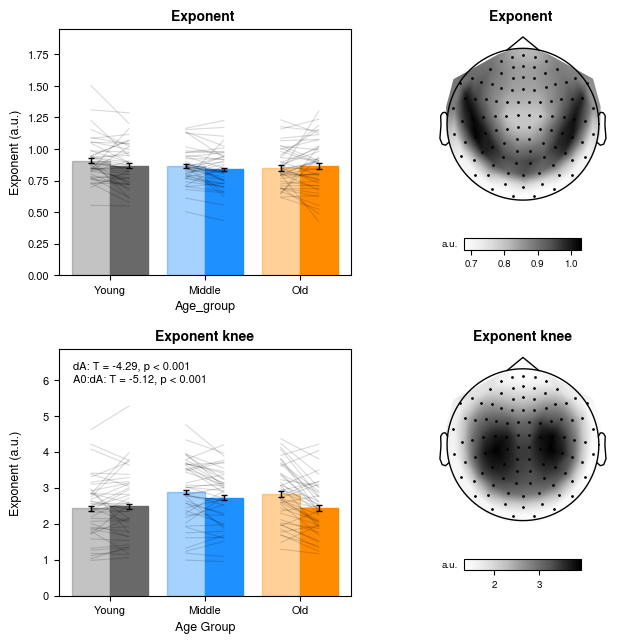

In [1]:
"""
Script to generate Supplementary Figure 5. It reads source data files created by 'supp_figure05_source_data.ipynb'.
"""

import os
import sys
import pandas as pd
import numpy as np
import mne
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec
import starbars
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

datadir = os.path.abspath(os.path.join(os.path.dirname( os.getcwd() ), '.', 'data'))
print(f'Data directory: {datadir}')

# --- Global Configuration Parameters ---
task = 'rest'
phases = ['p2', 'p5']

megtype = 'grad'
parameters = ['exponent']

# Create Age Groups
age_labels = ['Young', 'Middle', 'Old']

# --- HELPER FUNCTIONS for plotting ---
def plot_topo(var, pos, vardict, ax):
    """Generates standard MNE topo maps onto custom matplotlib subplots."""
    im, _ = mne.viz.plot_topomap(
        var, pos, mask=np.ones((len(var),), dtype=bool), mask_params={'markersize': 2, 'marker': '.'}, 
        cmap=vardict['cmap'], vlim=vardict['vlim'], image_interp='linear',
        contours=0, ch_type='mag', axes=ax, sensors='k.', show=False
    )
    ax.set_title(vardict['title'], fontdict={'fontsize': 10}, fontweight='bold')    
    return im

def plot_colorbar_horizontal(im, topo_ax, varunits):
    """Appends an aligned horizontal colorbar directly below spatial assets."""
    clb = plt.colorbar(mappable=im, ax=topo_ax, orientation='horizontal', location='bottom', aspect=10, shrink=0.5)
    clb.ax.tick_params(labelsize=7)
    clb.ax.set_ylabel(varunits, fontsize=7, rotation='horizontal', verticalalignment='center', labelpad=10)
    
    cbox = clb.ax.get_position()
    clb.ax.set_position([cbox.x0 - 0.034, cbox.y0, cbox.width, cbox.height])

def plot_bars_lines_annotations(df_data, col_x, col_y, col_hue, ax, title=None, ylabel=None, xlabel=None, ylim=None, col_error=None, indiv_values=None, annotations=None, stats=None):
    """Plots compound categorical bars, paired individual lines, and annotation boundaries."""
    sns.barplot(data=df_data, x=col_x, y=col_y, hue=col_hue, ax=ax)
    
    # Reorder to keep p2 and p5 adjacent for each categorical age cohort
    data_reordered = df_data.copy().loc[[0, 2, 4, 1, 3, 5], :].reset_index(drop=True)
    
    labels = [
        f"{row[col_x]} ({row['min_age']}-{row['max_age']} y), {row[col_hue]}".replace('p2', 'Phase 2').replace('p5', 'Phase 5')
        for _, row in df_data.iterrows()
    ]

    for bar, color in zip(ax.patches, data_reordered['Color']):
        bar.set_color(color)
    for bar, alpha in zip(ax.patches, data_reordered['Alpha']):
        bar.set_alpha(alpha)

    patches = [p for p in ax.patches if not np.isnan(p.get_height())]
    centers = np.array([p.get_x() + p.get_width() / 2 for p in patches])[0:6]
    heights = np.array([p.get_height() for p in patches])[0:6]

    yerr = df_data[col_error].to_numpy(float)[[0, 2, 4, 1, 3, 5]]
    ax.errorbar(centers, heights, yerr=yerr, fmt="none", ecolor="black", elinewidth=1, capsize=2, capthick=1, zorder=10)

    # Plot subject-level line connectivity across registration phases
    if indiv_values is not None:
        indiv_values_reordered = [indiv_values[idx] for idx in [0, 2, 4, 1, 3, 5]]
        for i in range(3):
            for subj in indiv_values_reordered[i].keys():
                if subj in indiv_values_reordered[i] and subj in indiv_values_reordered[i+3]:
                    ax.plot([centers[i], centers[i+3]], [indiv_values_reordered[i][subj], indiv_values_reordered[i+3][subj]], 
                            color='black', alpha=0.15, linewidth=0.8, zorder=5)

    if ylim is not None:
        ax.set_ylim(tuple(ylim))

    if annotations:
        starbars.draw_annotation(annotations, ax=ax, ns_show=False, bar_gap=0.02)

    ax.legend_ = None
    if title:
        ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_ylabel(ylabel if ylabel else col_y, fontsize=9)
    ax.set_xlabel(xlabel if xlabel else col_x, fontsize=9)
    ax.tick_params(axis='both', which='major', labelsize=8)

    # Contextual Statistical Annotation Summary Panel Overlay
    if stats is not None and len(stats) > 0:
        stats_clean = stats.copy()
        stats_clean['Effect'] = stats_clean['Effect'].str.replace('Age0', 'A0').str.replace('deltaAge', 'dA')
        box_text = ""
        for _, stat in stats_clean.iterrows():
            pvalue = stat['P']
            if pvalue < 0.05:
                p_txt = 'p < 0.001' if pvalue < 0.001 else 'p < 0.01' if pvalue < 0.01 else 'p < 0.05'
                box_text += f"{stat['Effect']}: T = {round(stat['T'], 2)}, {p_txt}\n"
        
        if box_text:
            ax.text(0.05, 0.95, box_text.strip(), fontsize=8, bbox=dict(boxstyle='round', fc='white', ec='white', alpha=0),
                    transform=ax.transAxes, horizontalalignment='left', verticalalignment='top', linespacing=1.3)

# --- CANVAS SETUP & PLOT INITIALIZATION ---

statsdf = pd.read_csv(os.path.join(datadir, f'supp_figure05_lme_results_combined_{megtype}.tsv'), sep='\t')

# Global plot settings
plt.rcParams.update({'font.size': 8, 'font.family': 'sans-serif', 'font.sans-serif': ['Nimbus Sans']})

# --- Create Figure and GridSpec Layout ---
fig = plt.figure(figsize=(7.2, 7))
gs = GridSpec(2, 2, width_ratios=[1, 0.8], wspace=0.3, hspace=0.3, left=0.11, right=0.95, top=0.94, bottom=0.13)

axs = np.array([[fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])],
                [fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1])]])

for k, kneemode in enumerate(['', 'knee']):
    knee_suffix = 'knee' if kneemode == 'knee' else 'fixed'
    
    for parameter in parameters:
        parameter_stats = statsdf[(statsdf['Parameter'] == f"{parameter.replace('_', ' ').title()} ({megtype})") & (statsdf['Kneemode'] == knee_suffix)]
        col_y = f'{parameter}_{megtype}'
        
        # =========================================================================
        # Read Bar Plot Summary Data (Group Means & SEMs)
        # =========================================================================
        summary_file = os.path.join(datadir, f'supp_figure05_barplot_summary_{knee_suffix}.tsv')
        df_data = pd.read_csv(summary_file, sep='\t')

        # =========================================================================
        # Read Long-Format Individual Subject Data (for Lines/Distribution)
        # =========================================================================
        indiv_file = os.path.join(datadir, f'supp_figure05_individual_values_{knee_suffix}.tsv')
        df_indiv = pd.read_csv(indiv_file, sep='\t')

        indiv_values = []
        for age_group in age_labels:
            for phase in phases:
                indiv_values.append(df_indiv[(df_indiv['Age_group'] == age_group) & (df_indiv['phase'] == phase)].set_index('subject')[parameter].to_dict())
       
        # =========================================================================
        # --- Pairwise and Population Statistical Annotations ---
        # =========================================================================
        annotations = []
               
        # Define dynamically adjusted figure bounds
        ylim = [0, float(max([df_data['Mean'].max()] + [v for dct in indiv_values for v in dct.values()])) * 1.3]

        # Plot the bars, lines, and annotations for the current parameter and kneemode
        plot_bars_lines_annotations(
            df_data=df_data, col_x='Age_group', col_y='Mean', col_hue='Phase', col_error='SEM', ax=axs[k, 0],
            title=f"{parameter.replace('_', ' ').replace('freq', 'frequency').title()} {kneemode}",
            ylabel='Exponent (a.u.)', xlabel='Age Group' if k == 1 else '', ylim=ylim,
            indiv_values=indiv_values, stats=parameter_stats
        )

        # --- Topographic Map Rendering Step ---
        if 'exponent' in parameter:
            ax_topo = axs[k, 1]
            
            # read the source file with the topographic values and channel positions
            topo_file = os.path.join(datadir, f'supp_figure05_topography_means_{knee_suffix}.tsv')
            df_topo = pd.read_csv(topo_file, sep='\t')

            channels = df_topo['Channel'].tolist()
            topovals = df_topo.set_index('Channel')['Mean_Value']
            pos = df_topo.set_index('Channel')['Positions'].apply(lambda x: np.fromstring(x.strip('[]'), sep=' ')).tolist()
            pos = np.array(pos)

            # Plot the topography
            im = plot_topo(
                var=topovals, pos=pos, ax=ax_topo,
                vardict={
                    'cmap': 'Greys', 'vlim': (topovals.min(), topovals.max()),
                    'title': parameter.replace('_', ' ').replace('band ', '').title() + ' ' + kneemode
                }
            )

            plot_colorbar_horizontal(im, ax_topo, varunits='a.u.')
            topobox = ax_topo.get_position()
            ax_topo.set_position([topobox.x0 - 0.033, topobox.y0, topobox.width, topobox.height])
    
fig.align_ylabels(axs[:, 0])
plt.savefig('Supp_Figure05.png', dpi=300, format='png', transparent=False)
plt.show()